In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. In the above dataset

##### a. In case age is less than 18, replace it with mean of age values.

In [2]:
# Load the acquisition data
ca = pd.read_csv('Customer Acquisition.csv')
ca.head()

,No,Customer,Age,City,Product,Limit,Company,Segment
0,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed
1,2,A2,71,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
2,3,A3,34,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
3,4,A4,47,BOMBAY,Platimum,10001.0,C4,Govt
4,5,A5,56,BANGALORE,Platimum,10002.0,C5,Normal Salary


In [3]:
# Step 1: Calculate mean age BEFORE any replacement (uses original, unfixed values)
ca['Age'] = ca['Age'].astype(float)
mean_age = ca['Age'].mean()
print(f'Mean age (before fixing): {mean_age}')

Mean age (before fixing): 46.49


In [4]:
# Step 2: Replace any Age < 18 with that mean value
ca.loc[ca['Age'] < 18, 'Age'] = mean_age

In [5]:
# Step 3: Sanity check - confirm no age below 18 remains
print(f'Any age still below 18?: {(ca['Age'] < 18).any()}\n')
print(f'Five Number Summary: \n{ca['Age'].describe()}')

Any age still below 18?: False

Five Number Summary: 
count    100.000000
mean      48.399400
std       16.402368
min       19.000000
25%       35.000000
50%       46.745000
75%       60.250000
max       79.000000
Name: Age, dtype: float64


##### b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit. (customer’s limit provided in acquisition table is the per transaction limit on his card)

In [6]:
# Load the spend table
sp = pd.read_csv('spend.csv')
sp.head()

,Sl No:,Customer,Month,Type,Amount
0,1,A1,12-Jan-04,JEWELLERY,485470.80
1,2,A1,3-Jan-04,PETRO,410556.13
2,3,A1,15-Jan-04,CLOTHES,23740.46
3,4,A1,25-Jan-04,FOOD,484342.47
4,5,A1,17-Jan-05,CAMERA,369694.07


In [7]:
# Step 1: Bring Limit into the Spend table by merging on customers
# how='left' -> keep all rows from spend.csv, just attach Limit where a match exists.
sp = sp.merge(ca[['Customer', 'Limit']], on='Customer', how='left') 

In [8]:
# Step 2: Whenever Amount > Limit, replace Amount with 50% of that row's limit
sp.loc[sp['Amount'] > sp['Limit'], 'Amount'] = 0.5 * sp['Limit']

In [9]:
# Sanity check: no spend should now exceed the limit
print(f'Any spend still above limit: {(sp['Amount'] > sp['Limit']).any()}')

Any spend still above limit: False


##### c. In case the repayment amount is more than the limit, replace the repayment with the limit.

In [10]:
# Load the Repayment table
rp = pd.read_csv('Repayment.csv')
rp.head()

,SL No:,Customer,Month,Amount,Unnamed: 4
0,NaN,A1,12-Jan-04,495414.75,NaN
1,2.0,A1,3-Jan-04,245899.02,NaN
2,3.0,A1,15-Jan-04,259490.06,NaN
3,4.0,A1,25-Jan-04,437555.12,NaN
4,5.0,A1,17-Jan-05,165972.88,NaN


In [11]:
# Step 1: Bring Limit into Repayment table by merging on customers
rp = rp.merge(ca[['Customer', 'Limit']], on='Customer', how='left')

In [12]:
# Step 2: Whenever Amount > Limit, replace Amount with limit
rp.loc[rp['Amount'] > rp['Limit'], 'Amount'] = rp['Limit']

In [13]:
# Sanity check: no repayment should exceed the limit
print(f'Any repayment should above the limit: {(rp['Amount'] > rp['Limit']).any()}')

Any repayment should above the limit: False


### 2. From the above dataset create the following summaries:

##### a. How many distinct customers exist?

In [14]:
# use nunique() method to find the distinct customers
num_distinct_customers = sp['Customer'].nunique()
num_distinct_customers

100

##### b. How many distinct categories exist?

In [15]:
# Product categories unique value count
num_of_distinct_product_categories = ca['Product'].nunique()
num_of_distinct_product_categories

3

In [16]:
# Type categories unique value count
num_of_distinct_type_categories = sp['Type'].nunique()
num_of_distinct_type_categories

15

##### c. Average Monthly Spend by Customers

**Assumption:** "Average monthly spend by customer" is interpreted as the average total spend across all customers, per month (bank-wide monthly average) - not the average spend of each individual customer.

In [17]:
# Convert the Month column (currently plain text like '12-Jun-04) into a real datetime. 
sp['Month'] = pd.to_datetime(sp['Month'], format='%d-%b-%y')

# Sanity check
print(sp[['Month']].head(), "\n")
print(sp['Month'].dtype)

       Month
0 2004-01-12
1 2004-01-03
2 2004-01-15
3 2004-01-25
4 2005-01-17 

datetime64[ns]


In [18]:
# Step 1: Creating a new column for each calendar month
sp['Month_Period'] = sp['Month'].dt.to_period('M')

In [19]:
# Step 2: Total spend across ALL customers, for each calendar month
monthly_total_spend = sp.groupby('Month_Period')['Amount'].sum()

In [20]:
# Step 3: Average of those monthly totals
average_monthly_spend = monthly_total_spend.mean()
print(f'Average monthly spend (bank-wide): {average_monthly_spend:.2f}')

Average monthly spend (bank-wide): 7326036.17


##### d. What is the average monthly repayment by customers?

In [21]:
# Drop the 23 full-blank rows first. 
rp = rp.dropna(how='all')

# Drop the junk empty column
rp = rp.drop(columns='Unnamed: 4')

In [22]:
# Convert the month in correct format
rp['Month'] = pd.to_datetime(rp['Month'], format='%d-%b-%y')

In [23]:
# Step 1: Create a new column name monthly_period, for each calendar month
rp['Month_Period'] = rp['Month'].dt.to_period('M')

In [24]:
# Step 2: Total repayment across all customers, for each calendar month
monthly_total_repayment = rp.groupby('Month_Period')['Amount'].sum()

In [25]:
# Step 3: Average of those monthly totals
average_monthly_repayment = monthly_total_repayment.mean()

print(f'Average monthly repayment: {average_monthly_repayment:.2f}')

Average monthly repayment: 8166078.67


##### e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? 

In [26]:
# Step 1: Total spend per calendar month 
monthly_spend = sp.groupby('Month_Period')['Amount'].sum()

In [27]:
# Step 2: Total repayment per calendar month
monthly_repayment = rp.groupby('Month_Period')['Amount'].sum()

In [28]:
# Step 3: Monthly Profit = Repayment - Spend, aligned by Month_Period
monthly_profit = monthly_repayment - monthly_spend

In [29]:
# Step 4: Clip negative profits to 0 (interest only on positive profit)
monthly_profit_clipped = monthly_profit.clip(lower=0)

In [30]:
# Step 5: Apply 2.9% monthly interest rate
monthly_interest_profit = monthly_profit_clipped * 0.029

print(f'--- Monthly Interest Profit ---\n{monthly_interest_profit.head()}')

--- Monthly Interest Profit ---
Month_Period
2004-01    14854.05404
2004-02        0.00000
2004-03    23043.57255
2004-04    51607.36760
2004-05    47449.29395
Freq: M, Name: Amount, dtype: float64


##### f. What are the top 5 product types?

In [31]:
type_totals = sp.groupby('Type')['Amount'].sum()
top_5_types = type_totals.sort_values(ascending=False).head(5)
top_5_types

Type
PETRO           28597384.98
CAMERA          27690738.44
FOOD            20519243.60
AIR TICKET      20155847.12
TRAIN TICKET    19995825.72
Name: Amount, dtype: float64

##### g. Which city is having maximum spend?

In [32]:
# Bring city into the Spend table 
new_sp = sp.merge(ca[['Customer', 'City']], on='Customer', how='left')

In [33]:
# Total spend per city
city_total = new_sp.groupby('City')['Amount'].sum()

In [34]:
# Find the city with the Maximum total spend
max_spend_city = city_total.idxmax()
max_spend_value = city_total.max()

print(f'--- City with maximum spend ---\n{max_spend_city} = {max_spend_value}')

--- City with maximum spend ---
COCHIN = 45963513.5


##### h. Which age group is spending more money?

In [35]:
# Step 1: Age binning
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
ca['Age_Group'] = pd.cut(ca['Age'], bins=bins, labels=labels)



In [36]:
sp = sp.merge(ca[['Customer', 'Age_Group']], on='Customer', how='left')

In [37]:
age_group_totals = sp.groupby('Age_Group')['Amount'].sum().sort_values(ascending=False)

print(f'--- Age group which spend more money: ---\n {age_group_totals.head(1)}')

--- Age group which spend more money: ---
 Age_Group
46-55    60884178.22
Name: Amount, dtype: float64


C:\Users\khush\AppData\Local\Temp\ipykernel_19544\1419690347.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_totals = sp.groupby('Age_Group')['Amount'].sum().sort_values(ascending=False)


##### i. Who are the top 10 customers in terms of repayment?

In [38]:
top_customers = rp.groupby('Customer')['Amount'].sum().sort_values(ascending=False)
top_customers.head(10)

Customer
A61    10539142.91
A60     9876290.74
A13     9572000.66
A43     8489871.46
A45     8448334.87
A12     8334760.16
A14     7943268.63
A44     7744730.12
A39     7622483.30
A42     7615460.86
Name: Amount, dtype: float64

### 3. Calculate the city wise spend on each product on yearly basis. Also include a graphical representation for the same.

In [39]:
sp = sp.merge(ca[['Customer', 'City', 'Product']], on='Customer', how='left')

In [40]:
sp['Year'] = sp['Month'].dt.year

In [41]:
city_wise_product_spend = sp.groupby(['City', 'Product', 'Year'])['Amount'].sum()
city_wise_product_spend

City        Product   Year
BANGALORE   Gold      2004     9289878.54
                      2005    12892362.99
                      2006    12030611.09
            Platimum  2004     1112732.30
                      2005      912284.97
                                 ...     
TRIVANDRUM  Platimum  2005     3601443.30
                      2006     2147403.75
            Silver    2004      209667.48
                      2005      269912.99
                      2006      555862.12
Name: Amount, Length: 72, dtype: float64

In [42]:
# Unstack Year into columns -> rows = City + Product, columns = Year
plot_data = city_wise_product_spend.unstack('Year')

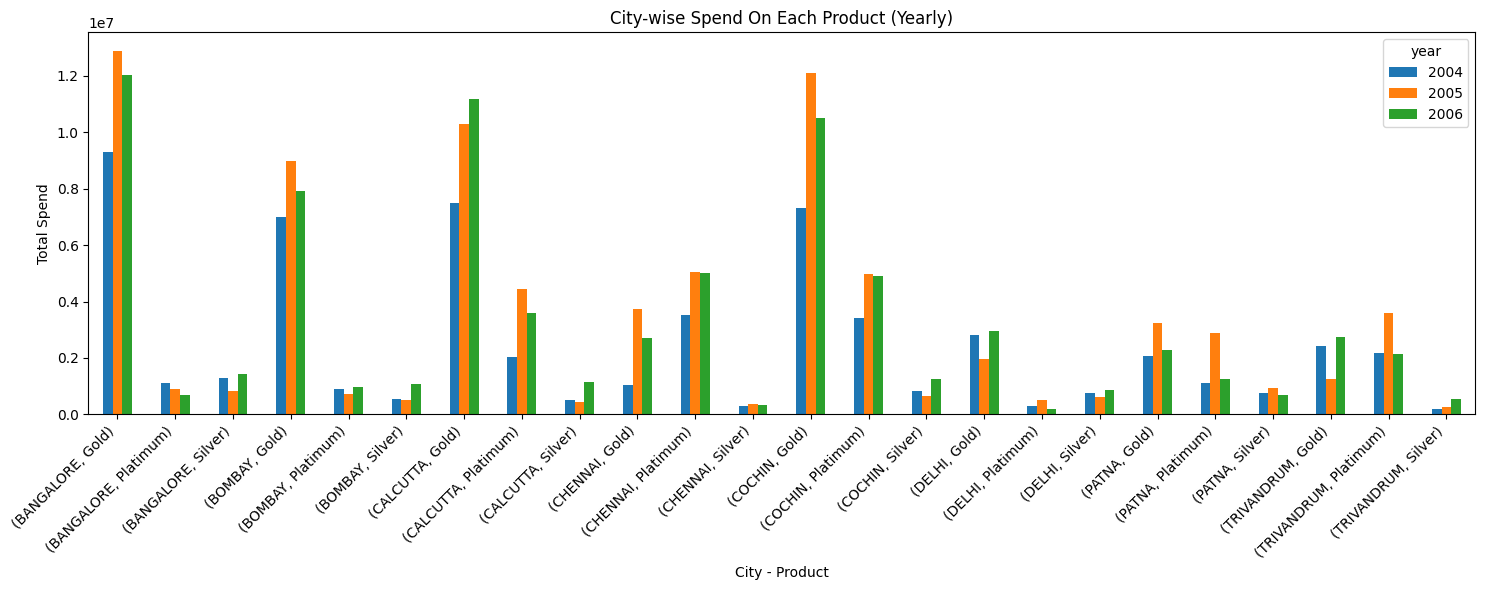

In [43]:
# Plot grouped bar chart
plot_data.plot(kind='bar', figsize=(15, 6))
plt.title('City-wise Spend On Each Product (Yearly)')
plt.xlabel('City - Product')
plt.ylabel('Total Spend')
plt.xticks(rotation=45, ha='right')
plt.legend(title='year')
plt.tight_layout()
plt.show()

### 4. Create graphs for

##### a. Monthly comparison of total spends, city wise

In [44]:
# Step 1: Find the monthly total spend comparison according to city
city_monthly_spend = sp.groupby(['City', 'Month_Period'])['Amount'].sum()
city_monthly_spend

City        Month_Period
BANGALORE   2004-01         8662102.77
            2004-02          535939.92
            2004-03           82428.80
            2004-04         1405495.85
            2004-05          783277.82
                               ...    
TRIVANDRUM  2006-07          250483.50
            2006-09          186063.70
            2006-10          212421.86
            2006-11           13756.30
            2006-12          338008.71
Name: Amount, Length: 212, dtype: float64

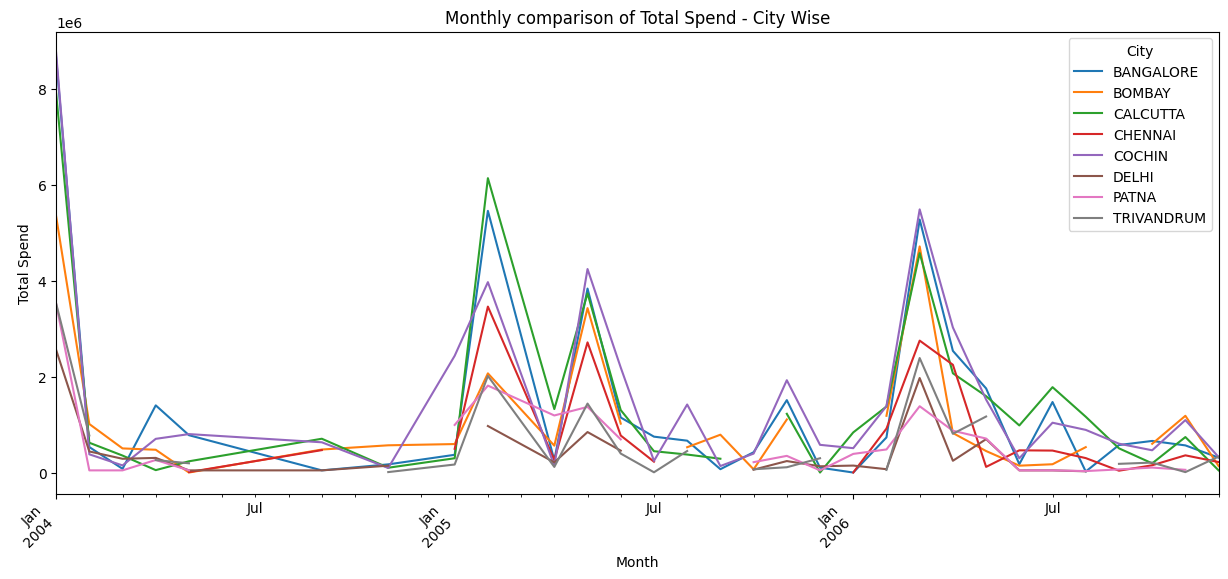

In [45]:
# Unstack City into columns -> rows = Month_Period, columns = City
city_plot_data = city_monthly_spend.unstack('City')

# Graph plotting
city_plot_data.plot(kind='line', figsize=(15, 6))
plt.title('Monthly comparison of Total Spend - City Wise')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.xticks(rotation=45, ha='right')
plt.legend(title='City')
# plt.tight_layout()
plt.show()

##### b. Comparison of yearly spend on air tickets

In [46]:
# Step 1: We have to create a new table where only the Air Ticket data is exist. 
air_ticket = sp[sp['Type'] == 'AIR TICKET']

In [47]:
# Step 2: Compare the yearly spend on air tickets
yearly_spend_on_air_tickets = air_ticket.groupby('Year')['Amount'].sum()

In [48]:
yearly_spend_on_air_tickets

Year
2004     4357225.35
2005    10550152.21
2006     5248469.56
Name: Amount, dtype: float64

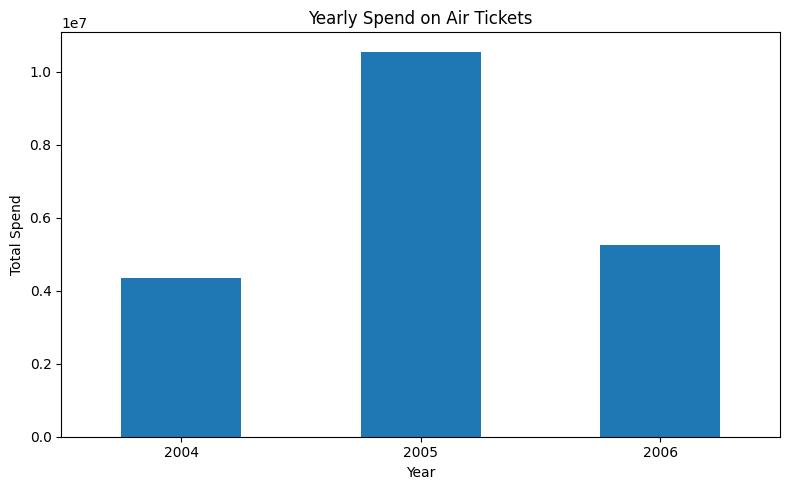

In [49]:
# Graph plotting
yearly_spend_on_air_tickets.plot(kind='bar', figsize=(8, 5))
plt.title('Yearly Spend on Air Tickets')
plt.xlabel('Year')
plt.ylabel('Total Spend')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### c. Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend)

In [ ]:
# Step 1: Extract just the month number (1-12), year is irrelevant for seasonality
sp['Month_Num'] = sp['Month'].dt.month

In [70]:
# Step 2: Group by Type and Month_Num -> Total spend per product per month
monthly_product_spend = sp.groupby(['Type', 'Month_Num'])['Amount'].sum()

In [72]:
# Step 3: Unstack Type -> rows = Month_Num (1, 12), columns = each product type
monthly_product_pivot = monthly_product_spend.unstack('Type') 

In [75]:
monthly_product_pivot.head()

Type,AIR TICKET,AUTO,BIKE,BUS TICKET,CAMERA,CAR,CLOTHES,FOOD,JEWELLERY,MOVIE TICKET,PETRO,RENTAL,SANDALS,SHOPPING,TRAIN TICKET
Month_Num,,,,,,,,,,,,,,,
1,3883744.92,254745.28,1639506.74,3563648.59,11193959.25,1808285.79,2390038.78,6249105.66,1983933.39,2267646.72,4935552.83,2662585.26,937690.61,5597576.04,2203774.10
2,3942051.05,919326.20,819351.79,3304006.38,1068316.33,458604.82,2970455.87,1540180.78,3344010.63,2932140.24,5652128.69,1885475.54,311318.82,3172223.81,3680661.55
3,1247589.11,2189907.85,1065987.87,355571.30,5070059.98,1813511.58,3978231.93,3136300.83,626304.11,885885.80,3656791.55,59511.10,1142466.65,1549437.75,3677658.58
4,1066444.18,354503.56,234402.47,890245.38,2895448.28,5001.00,219101.21,1897313.20,1253100.74,1785541.81,1625302.14,1151419.76,50000.00,3104228.77,3723336.60
5,4220999.91,298490.72,1925607.71,3835259.87,1669500.61,6588.51,1631257.34,4958123.90,1996282.25,2552460.42,3639517.93,2135172.56,50001.50,904773.67,2016999.36


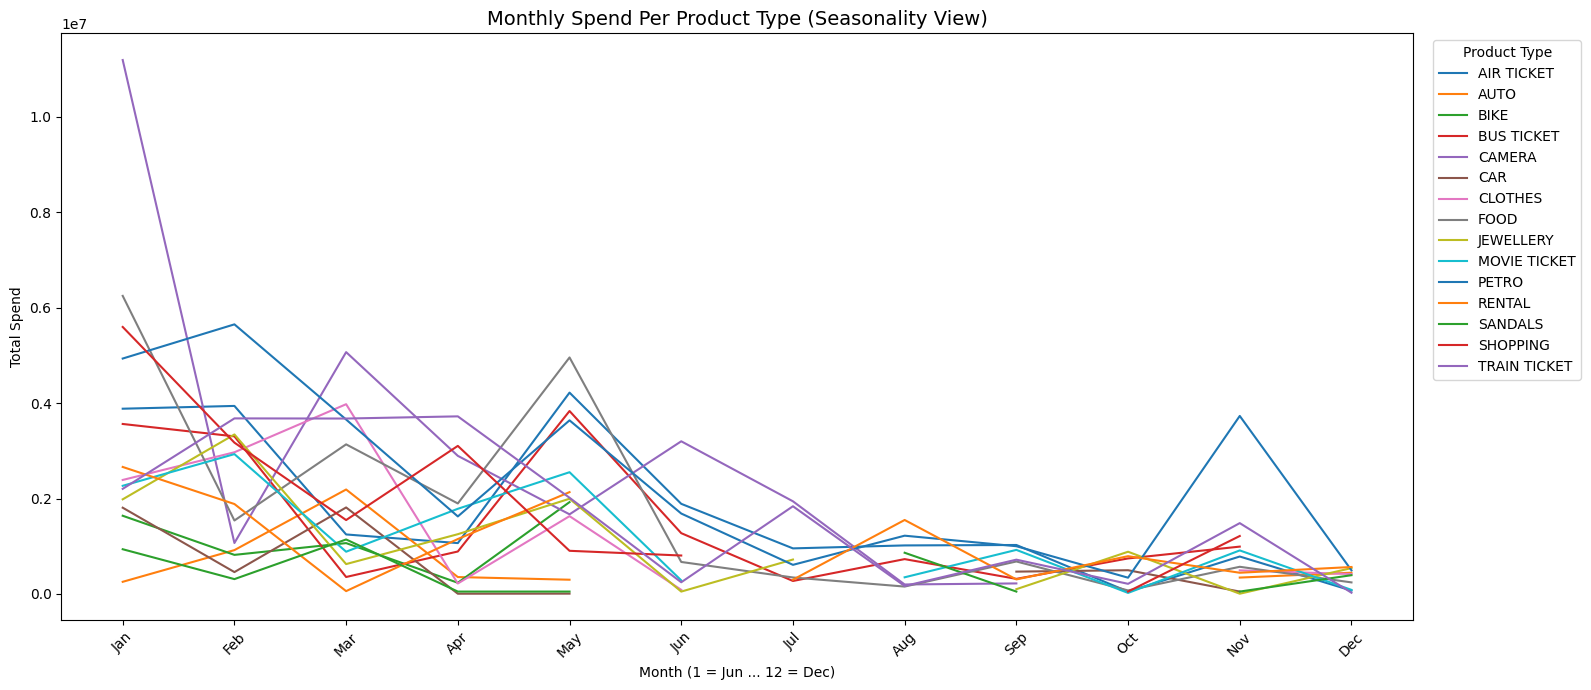

In [87]:
# Step 4: Plot - each product type is one line across 12 months
monthly_product_pivot.plot(kind='line', figsize=(16, 7))

plt.title('Monthly Spend Per Product Type (Seasonality View)', fontsize=14)
plt.xlabel('Month (1 = Jun ... 12 = Dec)')
plt.ylabel('Total Spend')
plt.xticks(
    ticks=range(1, 13), 
    labels=['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45
)
plt.legend(title='Product Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5. Write user defined PYTHON function to perform the following analysis:

In [90]:
# Bring City and Product into the repayment table from acquisition table
rp = rp.merge(ca[['Customer', 'City', 'Product']], on='Customer', how='left')

# Extract Year and Month number from the Month column
rp['Year'] = rp['Month'].dt.year
rp['Month_Num'] = rp['Month'].dt.month

In [94]:
def top10_customers_by_city(product, time_period): 
    """
    Return top 10 customers per city by total repayment amount. 

    Parameters: 
        product: str -> 'Gold', 'Silver', or 'Platinum'
        time_period: str -> 'yearly' or 'monthly'
    
    Returns: 
        DataFrame with top 10 customers per city for the given inputs. 
    """

    # Input validation: catch typos early 
    valid_products = rp['Product'].unique()
    valid_periods = ['yearly', 'monthly']

    if product not in valid_products: 
        print(f"Invalid product '{product}'. Choose from: {list(valid_products)}")
        return None
    
    if time_period not in valid_periods:
        print(f"Invalid time_period '{time_period}'. Choose from: {list(valid_periods)}")
        return None
    
    
    # Step 1: Filter to the requested product
    filtered = rp[rp['Product'] == product].copy()


    # Step 2: Choose grouping columns based on the time_period
    if time_period == 'yearly': 
        group_cols = ['City', 'Customer', 'Year']
    else: 
        group_cols = ['City', 'Customer', 'Month_Num']
    

    # Step 3: Total repayment per customer per city per time period
    grouped = (
        filtered
            .groupby(group_cols)['Amount']
            .sum()
            .reset_index()
            .rename(columns={'Amount': 'Total Repayment'})
    )


    # Step 4: Within each city, keep only the top 10 customers
    top10 = (
        grouped
        .sort_values('Total Repayment', ascending=False)
        .groupby('City')
        .head(10)
        .sort_values(['City', 'Total Repayment'], ascending=[True, False])
        .reset_index(drop=True)
    )

    return top10

In [97]:
# Test calls
print("=== Top 10 | Gold | Yearly ===")
print(top10_customers_by_city('Gold', 'yearly'))

=== Top 10 | Gold | Yearly ===
          City Customer  Year  Total Repayment
0    BANGALORE      A43  2005       4006956.60
1    BANGALORE      A13  2005       3757673.00
2    BANGALORE      A13  2006       3477314.89
3    BANGALORE      A14  2004       2770261.30
4    BANGALORE      A14  2006       2681025.72
5    BANGALORE      A30  2005       2667746.38
6    BANGALORE      A43  2006       2576417.39
7    BANGALORE      A14  2005       2491981.61
8    BANGALORE      A30  2006       2486958.41
9    BANGALORE       A1  2004       2359797.84
10      BOMBAY      A17  2006       3127783.14
11      BOMBAY      A42  2005       3125758.43
12      BOMBAY      A12  2006       3118090.96
13      BOMBAY      A42  2004       3045914.71
14      BOMBAY      A12  2005       2877588.30
15      BOMBAY      A12  2004       2339080.90
16      BOMBAY      A62  2004       1744114.25
17      BOMBAY      A62  2006       1684085.69
18      BOMBAY      A62  2005       1541617.21
19      BOMBAY      A42  2006

In [99]:
print("\n=== Testing invalid input ===")
top10_customers_by_city('Bronze', 'yearly')


=== Testing invalid input ===
Invalid product 'Bronze'. Choose from: ['Gold', 'Silver', 'Platimum']
